<a href="https://colab.research.google.com/github/Kommmi/Quantum-Dynamical-Systems/blob/main/GQS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!rm -rf Quantum-Dynamical-Systems
# Clean slate
#!pip uninstall -y gqs
!git clone https://github.com/Kommmi/Quantum-Dynamical-Systems.git

# Move into the repo
%cd Quantum-Dynamical-Systems

# Install dependencies
!pip install -r requirements.txt

# Install the package in editable mode
!pip install -e .

from IPython.display import clear_output
clear_output()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from gqs.states import Initial_state, rho_single_spin, Reduced_state_single_site
from gqs.dynamics import Hamiltonian_QK, floquet_operator_from_H
from gqs.distances import Quantum_EMD, Psi_Dist, bures_distance
from gqs.gqs import GQS_Bloch_Sphere_chi
from gqs.perturbations import perturb_theta_phi_isotropic
from gqs.gamma import Avg_separation_rate_local, Compare_distances_QKT, Avg_separation_QKT
from gqs.stats import period_statistics_summary

print("Module ready to go :)")



Module ready to go :)


1. Define a multiqubit system - Hamiltonian
2. Define a multiqubit system - Global state
3. What happens to the global state of the system? - correlation, entanglement, distance between states
4. How does this influence the local state?
5. Define local state - density matrix, GQS and plot and show what they look like
6. Define distance between local states- Bures
7. Define distance between local states- Earth mover's distance
8. An example
9. Average change in distance ove neighbors
10. Notebook-2 Different statistical measures and their significance


<summary><strong>Global Hamiltonian and Generation of Correlations</strong></summary>

We consider a many-body quantum system evolving under a **global Hamiltonian** that allows interactions among all subsystems. Although the total system is closed and evolves unitarily, such interactions generically generate correlations and entanglement between subsystems as time progresses.

As a concrete example, we study the quantum kicked top, whose Hamiltonian is given by

$$
H(t) = \frac{\pi}{2\tau} J_y
+ \frac{\kappa}{2j} J_z^2 \sum_{n=1}^{N}\delta(t-n\tau).
$$

The first term generates a collective rotation of all spins about the $y$-axis by an angle $\pi/2$.  
The second term introduces nonlinear interactions between spins with strength $ \kappa/2j$, which becomes explicit upon expanding

$$
J_z = \frac{\hbar}{2}\sum_i \sigma_z^{(i)}.
$$

The unitary evolution over one cycle is given by the floquet operator:
$$U_F = e^{-i(κ/2j \hbar)J_z^2}e^{-i(\pi/2\hbar)J_y}$$

The resulting Floquet operator drives the system away from product structure, generating multipartite entanglement.




In [3]:
# Constructing the Hamiltonian and Floquet operator - 3 qubit Quantum kicked top
dhilbert,nqubit = 2, 3
#___________Hamiltonian and Floquet operator___________
tau,kappa,hbar=1.0,2.5,1.0
order="free_then_kick"
H1, H2 = Hamiltonian_QK(tau, kappa, nqubit)
U_F = floquet_operator_from_H(H1, H2, tau,hbar,order)

<summary><strong>Global States and Invariance of Distinguishability</strong></summary>

We initialize the full system in a globally pure, spin-coherent product state,

$$
|\psi(\theta,\phi)\rangle
= \cos\!\left(\tfrac{\theta}{2}\right)|0\rangle
+ e^{i\phi}\sin\!\left(\tfrac{\theta}{2}\right)|1\rangle,
\qquad
|\Psi_{SE}(0)\rangle
= \bigotimes_{\ell=1}^{L}|\psi(\theta,\phi)\rangle.
$$

A nearby global state is prepared with a slightly perturbed coherent preparation,

$$
|\Psi_{SE}'(0)\rangle
= \bigotimes_{\ell=1}^{L}|\psi(\theta_p,\phi_p)\rangle.
$$

The distance between these two globally pure states is quantified using the Fubini–Study metric,

$$
d =
\arccos
\frac{|\langle\Psi_{SE}(0)|\Psi_{SE}'(0)\rangle|}
{\sqrt{\langle\Psi_{SE}(0)|\Psi_{SE}(0)\rangle
\langle\Psi_{SE}'(0)|\Psi_{SE}'(0)\rangle}}.
$$

Because the global system evolves unitarily, this distance remains invariant for all times.


In [4]:
#___________Global Initial State___________
thet0,phi0 = np.pi/2, np.pi/2
Psi_0 = Initial_state(nqubit, thet0, phi0)
#__________Perturbed Initial State___________
Psi_p, thet_p, phi_p = perturb_theta_phi_isotropic(nqubit, thet0, phi0, angle_sigma=0.1)
print("Fubini-Study Distance between them", Psi_Dist(Psi_0,Psi_p))

Fubini-Study Distance between them 0.08440848433967832


<summary><strong>Local States and Emergence of Mixedness</strong></summary>

When focusing on a subsystem $S_a$, interactions generated by the global Hamiltonian entangle it with the rest of the system, causing the reduced state to become mixed.

The global state can be written as

$$
|\Psi_{SE}(t)\rangle
=\sum_{k=1}^{L_S}\sum_{j=1}^{L_E}
\psi_{kj}(t)\,
|s_k^{(a)}\rangle|e_j^{(\neq a)}\rangle.
$$

Tracing out the environment yields

$$
\rho^{S_a}(t)
=\sum_{j=1}^{L_E}\lambda_j^{E}(t)\,
|\chi_j^{S_a}(t)\rangle\langle\chi_j^{S_a}(t)|,
$$

with

$$
\lambda_j^{E}(t)=\sum_{k=1}^{L_S}|\psi_{kj}(t)|^2,
\qquad
|\chi_j^{S_a}(t)\rangle
=\frac{1}{\sqrt{\lambda_j^{E}(t)}}
\sum_{k=1}^{L_S}\psi_{kj}(t)|s_k^{(a)}\rangle.
$$

In [5]:
system_site = 0
# ________Reduced density matrices of the two Global States____________
rho_s0 = rho_single_spin(dhilbert, nqubit, system_site, Psi_0)
rho_sp = rho_single_spin(dhilbert, nqubit, system_site, Psi_p)
Dr0 = bures_distance(rho_s0, rho_sp)
print("Bures Distance between the two reduced density matrices:", Dr0)
#______Add Plotly plots to visualize the reduced density matrix


Bures Distance between the two reduced density matrices: 0.04874770958315323


<summary><strong>Geometric Quantum State Representation</strong></summary>

Rather than viewing the reduced state solely as a density matrix, we adopt the **geometric quantum state (GQS)** representation.

Each conditional pure state defines a point in projective Hilbert space,

$$
\mathbf{Z}_j^{S_a}(t)
=\big[c_1^{(j)}(t):\cdots:c_d^{(j)}(t)\big]
\in\mathbb{C}P^{d-1}.
$$

The reduced state is represented as a probability measure,

$$
Q^{S_a}(Z,t)
=\sum_{j=1}^{L_E}\lambda_j^{E}(t)\,
\delta\!\left(Z-\mathbf{Z}_j^{S_a}(t)\right).
$$

This representation retains the **geometric structure** of mixed quantum states.

In [6]:
# ________Reduced Geometric quantum state at site-a____________
chi_s0,lambda_e0 = Reduced_state_single_site(dhilbert,nqubit,system_site,Psi_SE=Psi_0)
chi_sp,lambda_ep = Reduced_state_single_site(dhilbert,nqubit,system_site,Psi_SE=Psi_p)

#________Distances between the two____________
Dl0 = Quantum_EMD(chi_s0,lambda_e0,chi_sp,lambda_ep)
print("Quantum EMD between the two GQS:", Dl0)

Quantum EMD between the two GQS: 0.04875258067535245


<summary><strong>Distances Between Local States</strong></summary>

Initially, local states are pure and distances reduce to the Fubini–Study metric.  
As entanglement develops, two complementary notions of distance are used.

### Density-matrix distance (Bures)
$$
d_B
=\sqrt{2-2\sqrt{F(\rho^{S_a},\rho^{S_a'})}}.
$$

### Wasserstein distance on GQS ensembles
$$
W_p(Q^{S_a},Q^{S_a'})
=
\left(
\inf_{\pi\in\Pi(Q^{S_a},Q^{S_a'})}
\sum_{i,j}\pi_{ij}\,
\mathbf{d}(\mathbf{Z}_i^{S_a},\mathbf{Z}_j^{S_a'})^p
\right)^{1/p}.
$$

Unlike operator-based metrics, Wasserstein distance captures **geometric transport and deformation** of quantum-state ensembles.

In [8]:
N_kicks = 200
Dg, Dl, Dr = Compare_distances_QKT(U_F,Psi_0,Psi_p,dhilbert,nqubit,system_site,N_kicks,renormalize=True,show_plt=False)

### Average local distance
The averages over multiple perturbations for a given initial state. Average Distance tells us how distinguishable the two local geometric quantum states or reduced density matrices remain as the system evolves. A positive average distance of separation impilies that overall the two states remain distinguishable. Reduced density matrices become less distinguishable with time

In [30]:
eps = 0.2
N_traj,N_kicks = 100, 500
data_dist=Avg_separation_QKT(dhilbert,nqubit,system_site,U_F,thet0,phi0,eps,N_traj,N_kicks)

In [31]:
ln_dl_GQS =data_dist['ln_avg_dist_L']
df,_ = period_statistics_summary(ln_dl_GQS)
display(df)

,quantity,value
0,dominant period,58.000000
1,average per period,0.340641
2,variance_per_period,0.043235
3,directional_asymmetry,0.063492


In [ ]:
ln_dl_R =data_dist['ln_avg_dist_R']
df,_ = period_statistics_summary(ln_dl_R)
display(df)

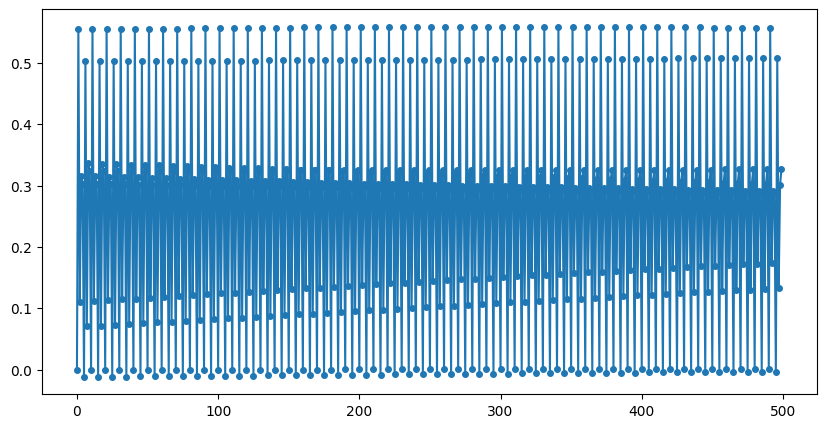

In [117]:
plt.figure(figsize=(10,5))
plt.plot(ln_dl, marker='o', markersize=4)
plt.show()

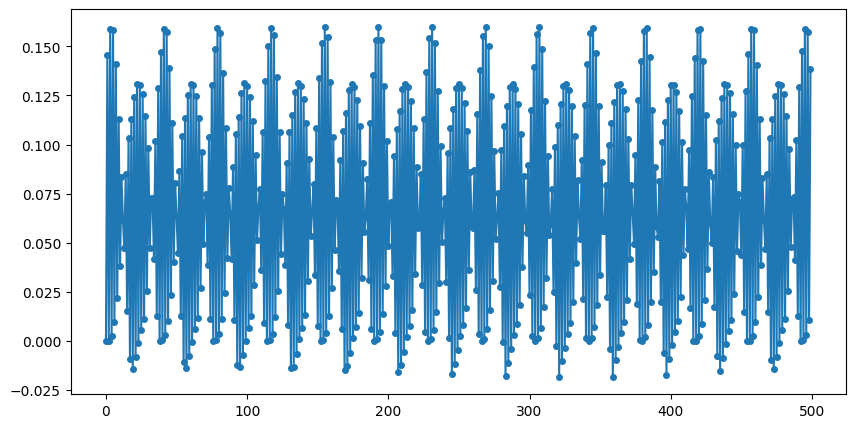

In [90]:
plt.figure(figsize=(10,5))
plt.plot(ln_dl, marker='o', markersize=4)
plt.show()

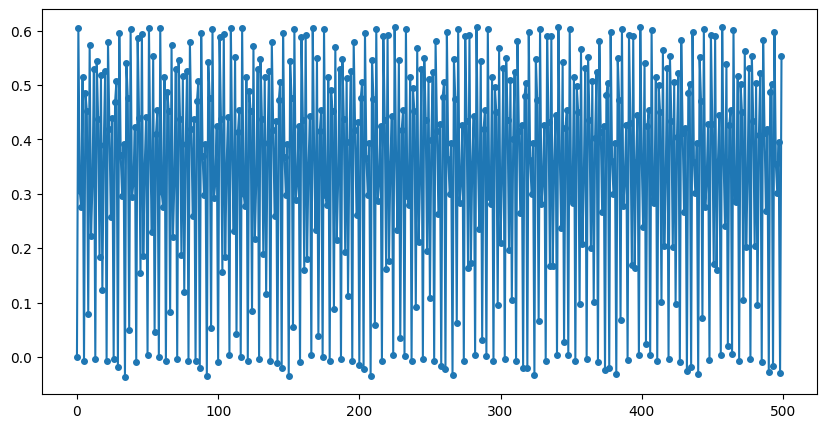

In [51]:
plt.figure(figsize=(10,5))
plt.plot(ln_dl, marker='o', markersize=4)
plt.show()

### Computing the period of the average ln(distance) vs kicks

1. compute the autocorrelation function
2. Add Bures metric